# 06 - Short Horizons (5-minute, 1-hour, 1-day)

Extends the macro-horizon approach to three shorter, more actionable horizons, all derived from the same underlying Binance 1-minute klines (resampled to each target frequency) so differences between horizons are genuinely about the horizon, not the data source.

**Calibration**: pooled across the 8 macro calm periods that fall after Binance's 2017 launch (`short_horizon_reference_periods`), the same "normal" definition macro uses wherever Binance actually has data.

**Scoring**: uniform, continuous scoring across `short_horizon_scoring_period` (2023-09-25 to 2026-08-31) -- not restricted to the 5 named macro events, since a macro-level regime label doesn't imply every short-horizon window inside it is itself anomalous, and real short-horizon anomalies could exist entirely outside those 5 windows.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from src.ingestion.binance import fetch_klines, resample_klines
from src.features.pipeline import HorizonConfig, raw_paths_by_reference_period, raw_paths_for_horizon, fit_reference_scale_multi
from src.paths.transforms import normalize, add_basepoint, apply_recency_weights
from src.models.expected_signature import ExpectedSignatureDistance
from src.models.tail_bounds import fit_weibull_tail, weibull_threshold
from src.evaluation.synthetic import auroc_vs_spike_magnitude

cfg = yaml.safe_load(open('../configs/horizons.yaml'))
calm_periods = cfg['short_horizon_reference_periods']
scoring_period = cfg['short_horizon_scoring_period']
halflife = cfg['recency_halflife_days']
symbol = cfg['asset']

# Load and concatenate all 1-minute data needed: the 3 older calm periods
# (individually cached) + the one continuous 2023-2026 block (covers the
# other 5 calm periods AND the uniform scoring range). All already cached --
# these calls hit disk, not the network.
older_calm = [p for p in calm_periods if p['start'] < '2021-01-01']
frames = [fetch_klines(symbol, '1m', p['start'], p['end']) for p in older_calm]
frames.append(fetch_klines(symbol, '1m', scoring_period['start'], scoring_period['end']))
klines_1m = pd.concat(frames).sort_index()
klines_1m = klines_1m[~klines_1m.index.duplicated()]
print(f'combined 1-minute data: {len(klines_1m)} rows, {klines_1m.index.min()} -> {klines_1m.index.max()}')

combined 1-minute data: 2043600 rows, 2018-08-13 00:00:00+00:00 -> 2026-08-31 23:59:00+00:00


## Build, calibrate, and score each horizon

For each horizon: resample once from the shared 1-minute source, pool the 8 calm periods (40% train / 60% calibration split per period), fit the recency-weighted expected-signature-distance model, run the synthetic sanity check, then score the *entire* continuous scoring period at fine (step=1) resolution -- uniformly, not restricted to any named event.

In [2]:
horizon_specs = [
    ('five_min', 'five_min_scoring', '5min'),
    ('one_hour', 'one_hour_scoring', '1h'),
    ('one_day', 'one_day_scoring', '1D'),
]

results = {}

for calib_name, score_name, rule in horizon_specs:
    print(f'=== {calib_name} ===')
    calib_cfg = HorizonConfig.from_dict(calib_name, cfg['horizons'][calib_name])
    score_cfg = HorizonConfig.from_dict(score_name, cfg['horizons'][score_name])
    # Scaled to this horizon's own window (macro's validated ratio, ~window/4)
    # -- NOT the shared macro recency_halflife_days, which only makes sense
    # in macro's own bar units (days).
    horizon_halflife = cfg['horizons'][calib_name]['recency_halflife_bars']

    bars = resample_klines(klines_1m, rule)

    scale = fit_reference_scale_multi(bars, calib_cfg, calm_periods)
    raw_by_period = raw_paths_by_reference_period(bars, calib_cfg, calm_periods)
    train_raw, calib_raw = [], []
    for pr in raw_by_period:
        cut = max(1, round(len(pr) * 0.4))
        train_raw.extend(pr[:cut]); calib_raw.extend(pr[cut:])

    def prep(paths, hl=horizon_halflife):
        return [add_basepoint(apply_recency_weights(normalize(p, scale), hl)) for p in paths]

    train_paths = prep(train_raw)
    calib_paths = prep(calib_raw)
    print(f'  {len(raw_by_period)} calm periods -> {len(train_paths)} train, {len(calib_paths)} calib windows, '
          f'halflife={horizon_halflife} bars')

    # synthetic sanity check (model fit on train, tested on held-out calib)
    channel = calib_cfg.channels.index('log_return')
    channel_std = np.std([p[-1, channel] for p in train_paths + calib_paths])
    magnitudes = [m * channel_std for m in [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]]
    model_train = ExpectedSignatureDistance(depth=calib_cfg.depth).fit(train_paths)
    synth = auroc_vs_spike_magnitude(calib_paths, model_train.score, channel=channel,
                                      magnitudes=magnitudes, n_per_class=100, seed=0)
    print('  synthetic AUROC:', {round(k, 2): round(v, 3) for k, v in synth.items()})

    # real model: same train/calib split, Weibull threshold at alpha=0.01
    model = ExpectedSignatureDistance(depth=calib_cfg.depth).fit(train_paths)
    calib_scores = model.score_many(calib_paths)
    A, B = fit_weibull_tail(calib_scores, N=calib_cfg.depth)
    try:
        thr = weibull_threshold(0.01, A, B, N=calib_cfg.depth)
    except ValueError as e:
        print(f'  Weibull threshold unsolvable ({e}); falling back to max(calib scores)')
        thr = float(calib_scores.max())
    print(f'  alpha=0.01 threshold: {thr:.4f}')

    # score the FULL continuous scoring period, fine step -- uniform, no event restriction
    scoring_bars = bars.loc[scoring_period['start']:scoring_period['end']]
    end_times, raw_score = raw_paths_for_horizon(scoring_bars, score_cfg)
    score_paths = prep(raw_score)
    score_series = pd.Series(model.score_many(score_paths), index=pd.DatetimeIndex(end_times))
    flag_rate = (score_series >= thr).mean()
    print(f'  scored {len(score_series)} windows over {scoring_period["start"]} -> {scoring_period["end"]}, '
          f'flag rate={flag_rate:.4%}')

    results[calib_name] = dict(synth=synth, threshold=thr, score_series=score_series, flag_rate=flag_rate,
                                n_train=len(train_paths), n_calib=len(calib_paths), halflife=horizon_halflife)
    print()

=== five_min ===


  8 calm periods -> 31909 train, 47862 calib windows, halflife=3 bars


  synthetic AUROC: {np.float64(0.0): 0.49, np.float64(0.8): 0.517, np.float64(1.6): 0.623, np.float64(3.2): 0.742, np.float64(6.41): 0.912, np.float64(12.82): 0.964}


  alpha=0.01 threshold: 143827.7071


  scored 308725 windows over 2023-09-25 -> 2026-09-25, flag rate=0.3498%

=== one_hour ===


...

  alpha=0.01 threshold: 5714529.1087


  scored 25705 windows over 2023-09-25 -> 2026-09-25, flag rate=1.1982%

=== one_day ===


  8 calm periods -> 213 train, 321 calib windows, halflife=2 bars


  synthetic AUROC: {np.float64(0.0): 0.482, np.float64(0.73): 0.589, np.float64(1.46): 0.529, np.float64(2.93): 0.617, np.float64(5.86): 0.803, np.float64(11.71): 0.926}
  alpha=0.01 threshold: 1121.4678


  scored 1066 windows over 2023-09-25 -> 2026-09-25, flag rate=0.3752%



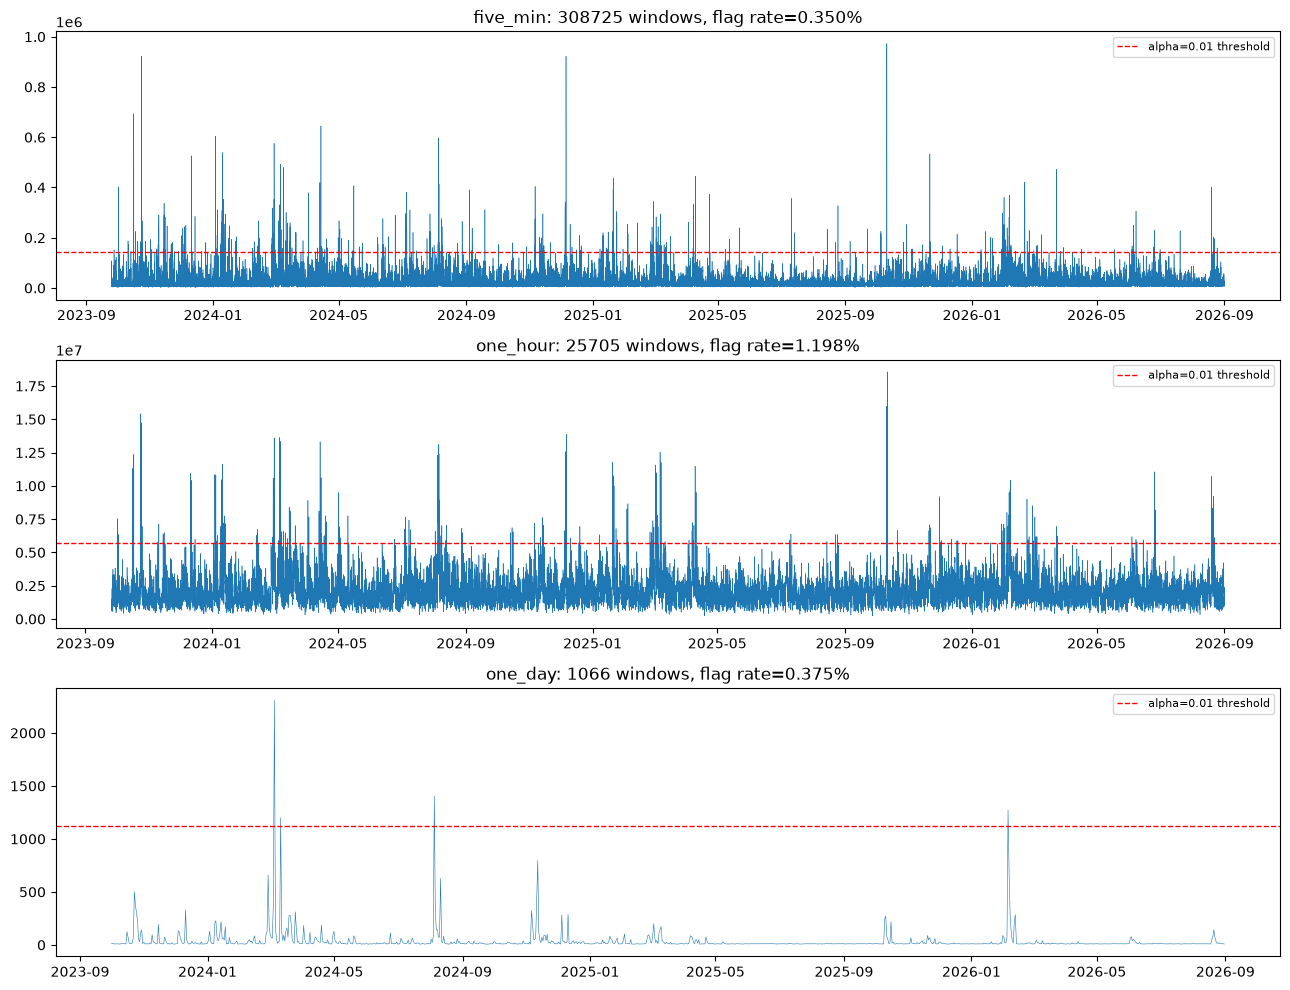

,horizon,train_windows,calib_windows,synthetic_auroc_max,threshold,scored_windows,flag_rate
0,five_min,31909,47862,0.9636,1.438277e+05,308725,0.003498
1,one_hour,1323,1984,0.9706,5.714529e+06,25705,0.011982
2,one_day,213,321,0.9262,1.121468e+03,1066,0.003752


In [3]:
fig, axes = plt.subplots(len(horizon_specs), 1, figsize=(13, 10), sharex=False)
for ax, (calib_name, _, _) in zip(axes, horizon_specs):
    r = results[calib_name]
    s = r['score_series']
    ax.plot(s.index, s.values, lw=0.4)
    ax.axhline(r['threshold'], color='red', ls='--', lw=1, label='alpha=0.01 threshold')
    ax.set_title(f'{calib_name}: {len(s)} windows, flag rate={r["flag_rate"]:.3%}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/short_horizons_scores.png', dpi=120)
plt.show()

summary_rows = []
for calib_name, _, _ in horizon_specs:
    r = results[calib_name]
    summary_rows.append({
        'horizon': calib_name,
        'train_windows': r['n_train'],
        'calib_windows': r['n_calib'],
        'synthetic_auroc_max': max(r['synth'].values()),
        'threshold': r['threshold'],
        'scored_windows': len(r['score_series']),
        'flag_rate': r['flag_rate'],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/short_horizons_summary.csv', index=False)
summary_df

## Forward-volatility event study: is a flag actually tradeable?

Everything above checks whether a flagged window's *own* price-shape looks unusual -- it never checks whether anything tradeable happens *afterward*. This is a separate question, and deliberately checked as a diagnostic on the already-calibrated detector, not used to redefine it: the threshold and calibration above don't change based on this result, so this doesn't reintroduce the label-circularity problem discussed earlier (defining the anomaly *as* "precedes high vol" would be circular; *checking* whether an independently-defined anomaly happens to precede high vol is not).

For each horizon, forward realized volatility is measured over the next N bars (N = that horizon's own window length, so look-back and look-forward are symmetric: 12 bars/1h for five_min, 24 bars/1 day for one_hour, 7 bars/~1 week for one_day), compared between flagged and non-flagged windows via a one-sided Mann-Whitney U test (non-parametric, robust to volatility's own skew, doesn't require assuming independence the way a t-test would).

In [4]:
from scipy.stats import mannwhitneyu

forward_horizon_bars = {'five_min': 12, 'one_hour': 24, 'one_day': 7}

event_study_rows = []
for calib_name, score_name, rule in horizon_specs:
    r = results[calib_name]
    s = r['score_series']
    thr = r['threshold']
    N = forward_horizon_bars[calib_name]

    bars = resample_klines(klines_1m, rule)
    close = bars['close']
    log_ret_all = np.log(close).diff()
    pos_of = {t: i for i, t in enumerate(close.index)}

    flagged_fwd_vol, normal_fwd_vol = [], []
    for t, score in s.items():
        pos = pos_of.get(t)
        if pos is None or pos + N + 1 > len(close):
            continue  # not enough forward data left at the very end of history
        fwd_vol = log_ret_all.iloc[pos + 1: pos + N + 1].std()
        (flagged_fwd_vol if score >= thr else normal_fwd_vol).append(fwd_vol)

    flagged_fwd_vol = np.array(flagged_fwd_vol)
    normal_fwd_vol = np.array(normal_fwd_vol)
    stat, pval = mannwhitneyu(flagged_fwd_vol, normal_fwd_vol, alternative='greater')
    med_flagged, med_normal = np.median(flagged_fwd_vol), np.median(normal_fwd_vol)
    ratio = med_flagged / med_normal

    print(f'{calib_name}: n_flagged={len(flagged_fwd_vol)}, n_normal={len(normal_fwd_vol)}, forward window={N} bars')
    print(f'  median forward realized vol | flagged = {med_flagged:.6f}')
    print(f'  median forward realized vol | normal  = {med_normal:.6f}')
    print(f'  ratio (flagged/normal) = {ratio:.2f}x   Mann-Whitney p-value (flagged > normal) = {pval:.3e}')
    print()

    event_study_rows.append(dict(
        horizon=calib_name, n_flagged=len(flagged_fwd_vol), n_normal=len(normal_fwd_vol),
        median_fwd_vol_flagged=med_flagged, median_fwd_vol_normal=med_normal,
        ratio=ratio, pvalue=pval,
    ))

event_study_df = pd.DataFrame(event_study_rows)
event_study_df.to_csv('../reports/short_horizons_forward_vol_study.csv', index=False)
event_study_df

five_min: n_flagged=1080, n_normal=307633, forward window=12 bars
  median forward realized vol | flagged = 0.003229
  median forward realized vol | normal  = 0.000977
  ratio (flagged/normal) = 3.31x   Mann-Whitney p-value (flagged > normal) = 0.000e+00



one_hour: n_flagged=308, n_normal=25373, forward window=24 bars
  median forward realized vol | flagged = 0.007170
  median forward realized vol | normal  = 0.004051
  ratio (flagged/normal) = 1.77x   Mann-Whitney p-value (flagged > normal) = 7.422e-85

one_day: n_flagged=4, n_normal=1055, forward window=7 bars
  median forward realized vol | flagged = 0.042229
  median forward realized vol | normal  = 0.020266
  ratio (flagged/normal) = 2.08x   Mann-Whitney p-value (flagged > normal) = 1.132e-02



,horizon,n_flagged,n_normal,median_fwd_vol_flagged,median_fwd_vol_normal,ratio,pvalue
0,five_min,1080,307633,0.003229,0.000977,3.305895,0.000000e+00
1,one_hour,308,25373,0.007170,0.004051,1.770079,7.421585e-85
2,one_day,4,1055,0.042229,0.020266,2.083716,1.132121e-02
